In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.float_format', lambda x: '{:.4f}'.format(x))
np.set_printoptions(suppress=True)

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Loan payback/loan_data.csv")
df.sample(4)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
20928,29.0000,male,Bachelor,54021.0000,5,MORTGAGE,21000.0000,HOMEIMPROVEMENT,10.9900,0.3900,8.0000,656,No,0
44490,25.0000,male,Bachelor,61130.0000,3,RENT,15890.0000,HOMEIMPROVEMENT,16.6800,0.2600,4.0000,584,No,1
38916,25.0000,male,Associate,144874.0000,5,MORTGAGE,10000.0000,MEDICAL,8.8000,0.0700,2.0000,648,Yes,0
31541,41.0000,male,Associate,123855.0000,21,MORTGAGE,8800.0000,MEDICAL,11.5800,0.0700,11.0000,697,Yes,0


In [3]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [5]:
df.loan_status.value_counts()

,count
loan_status,
0,35000
1,10000


In [6]:
X = df.drop("loan_status", axis="columns")
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

df_train = pd.concat([X_train, y_train], axis="columns")
df_test = pd.concat([X_test, y_test], axis="columns")

In [7]:
df_train.shape, df_test.shape

((33750, 14), (11250, 14))

In [8]:
df_train.head(2)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
12863,26.0000,female,Associate,102675.0000,5,MORTGAGE,6000.0000,EDUCATION,9.8800,0.0600,3.0000,654,No,0
12903,24.0000,male,Bachelor,84036.0000,0,RENT,12000.0000,DEBTCONSOLIDATION,10.2000,0.1400,4.0000,613,No,1


In [9]:
df_test.head(2)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
2799,22.0000,male,High School,71611.0000,0,RENT,12000.0000,PERSONAL,10.3700,0.1700,3.0000,659,No,0
23680,32.0000,female,Associate,78460.0000,13,OWN,10000.0000,VENTURE,11.9900,0.1300,5.0000,657,No,0


In [10]:
numerical_features = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'credit_score'
]

categorical_features = [
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

target = 'loan_status'
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target variable:", target)

Numerical features: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
Categorical features: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Target variable: loan_status


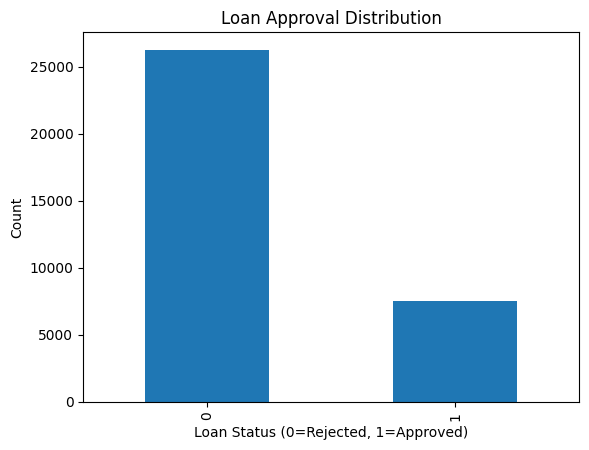

In [11]:
import matplotlib.pyplot as plt

df_train['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status (0=Rejected, 1=Approved)")
plt.ylabel("Count")
plt.show()

In [12]:
df_train['loan_status'].value_counts()

,count
loan_status,
0,26250
1,7500


In [13]:
df_train[numerical_features].describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
count,33750.0000,33750.0000,33750.0000,33750.0000,33750.0000,33750.0000,33750.0000,33750.0000
mean,27.7678,80627.8164,5.4097,9607.3740,11.0145,0.1398,5.8623,632.6294
std,6.0476,84880.6708,6.0659,6313.9866,2.9738,0.0871,3.8721,50.2614
min,20.0000,8000.0000,0.0000,500.0000,5.4200,0.0000,2.0000,390.0000
25%,24.0000,47293.7500,1.0000,5000.0000,8.5900,0.0700,3.0000,602.0000
50%,26.0000,67099.5000,4.0000,8000.0000,11.0100,0.1200,4.0000,640.0000
75%,30.0000,96602.5000,8.0000,12250.0000,13.0200,0.1900,8.0000,670.0000
max,144.0000,7200766.0000,125.0000,35000.0000,20.0000,0.6600,30.0000,850.0000


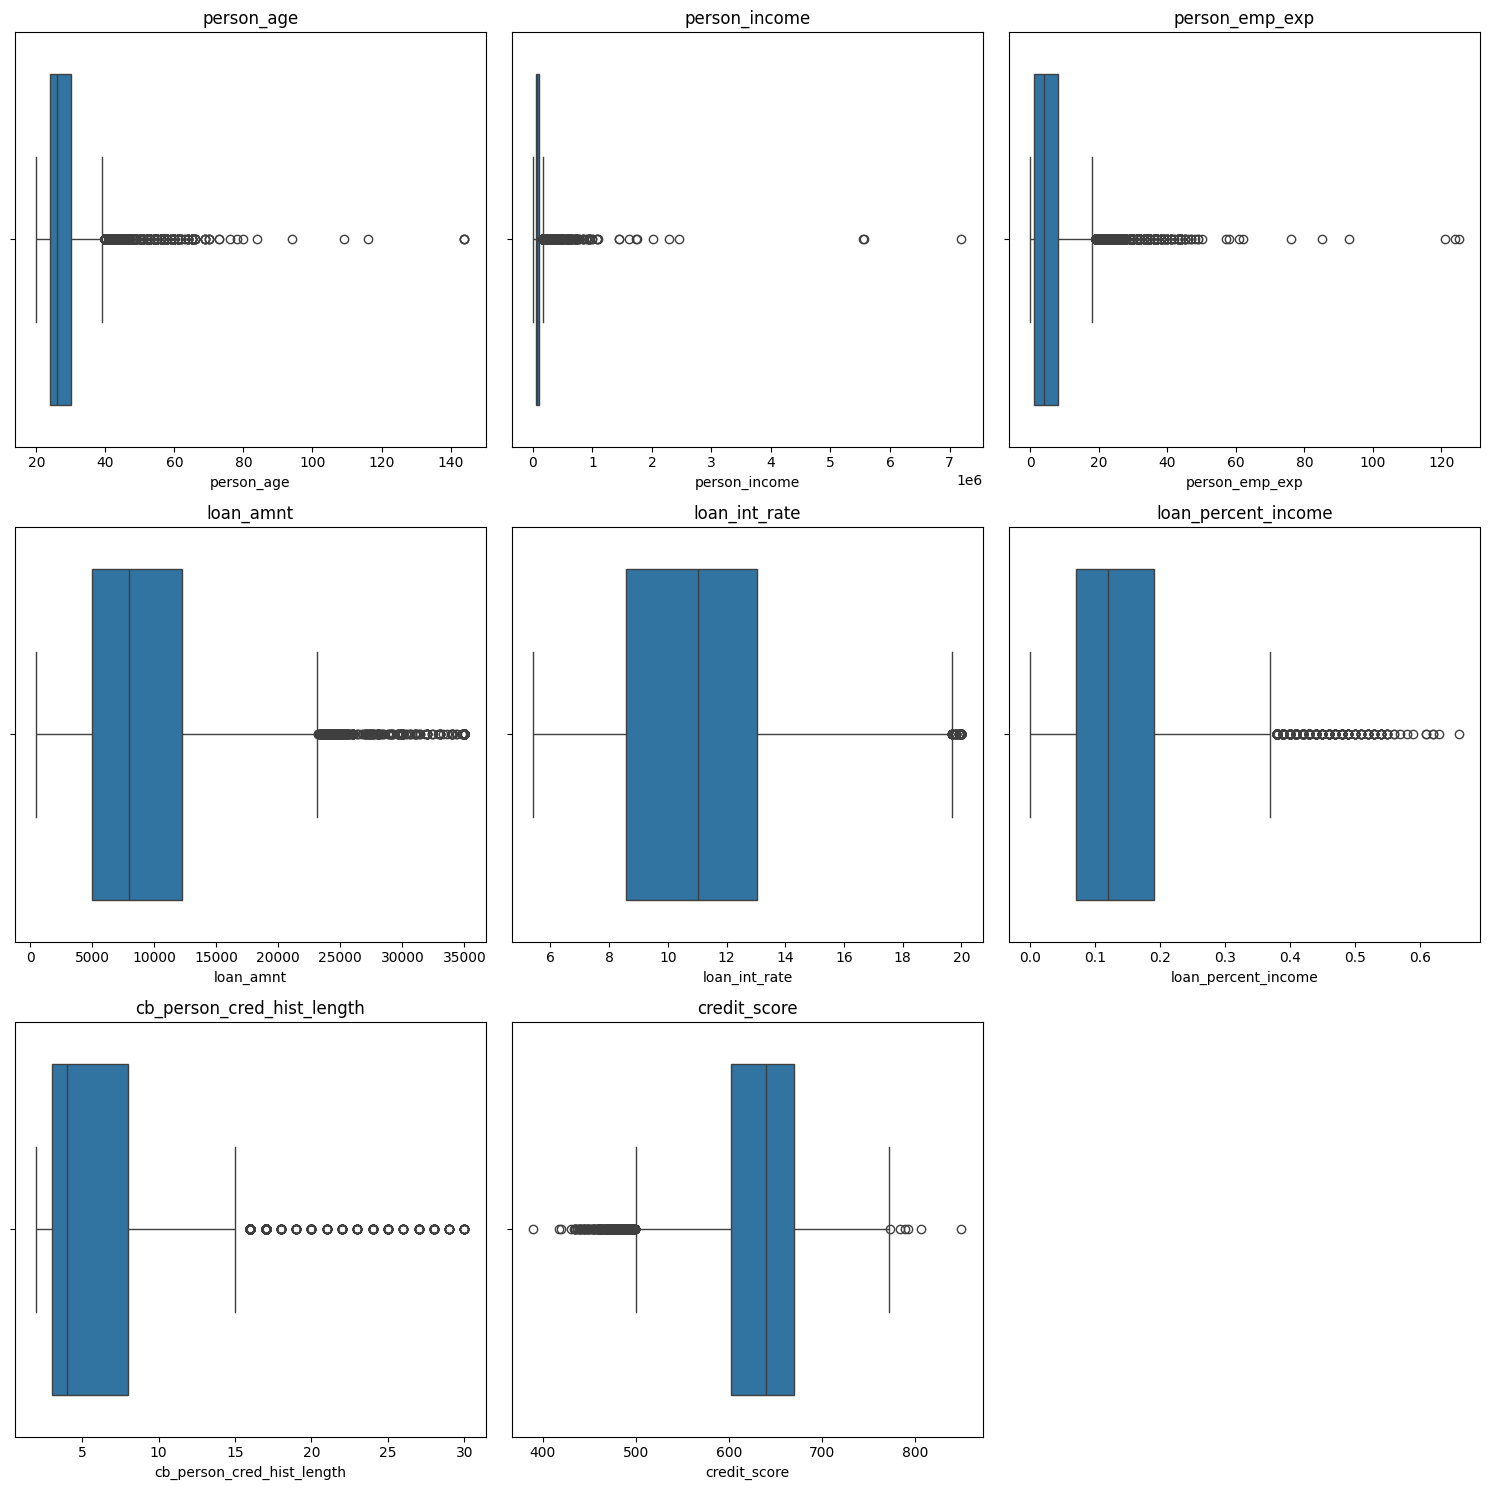

In [14]:
num_plots = len(numerical_features)
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
  sns.boxplot(x=df_train[col], ax=axes[i])
  axes[i].set_title(col)

for j in range(i+1, num_rows*num_cols):
  axes[j].axis('off')

plt.tight_layout()
plt.show()

In [15]:
df_train = df_train[df_train['person_age'] <= 80]

In [16]:
df_test = df_test[df_test['person_age'] <= 80]

In [17]:
df_train.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000
mean,27.7488,80081.7832,5.3905,9608.1129,11.0143,0.1398,5.8598,632.5975,0.2223
std,5.8931,62669.0246,5.9086,6314.3780,2.9740,0.0871,3.8658,50.2147,0.4158
min,20.0000,8000.0000,0.0000,500.0000,5.4200,0.0000,2.0000,390.0000,0.0000
25%,24.0000,47293.0000,1.0000,5000.0000,8.5900,0.0700,3.0000,602.0000,0.0000
50%,26.0000,67098.0000,4.0000,8000.0000,11.0100,0.1200,4.0000,640.0000,0.0000
75%,30.0000,96593.5000,8.0000,12250.0000,13.0200,0.1900,8.0000,669.0000,0.0000
max,80.0000,2448661.0000,62.0000,35000.0000,20.0000,0.6600,30.0000,772.0000,1.0000


In [18]:
num_cols = [
    'person_income',
    'loan_amnt',
    'loan_percent_income',
    'person_emp_exp'
]

for col in num_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_train[col] = df_train[col].clip(lower, upper)

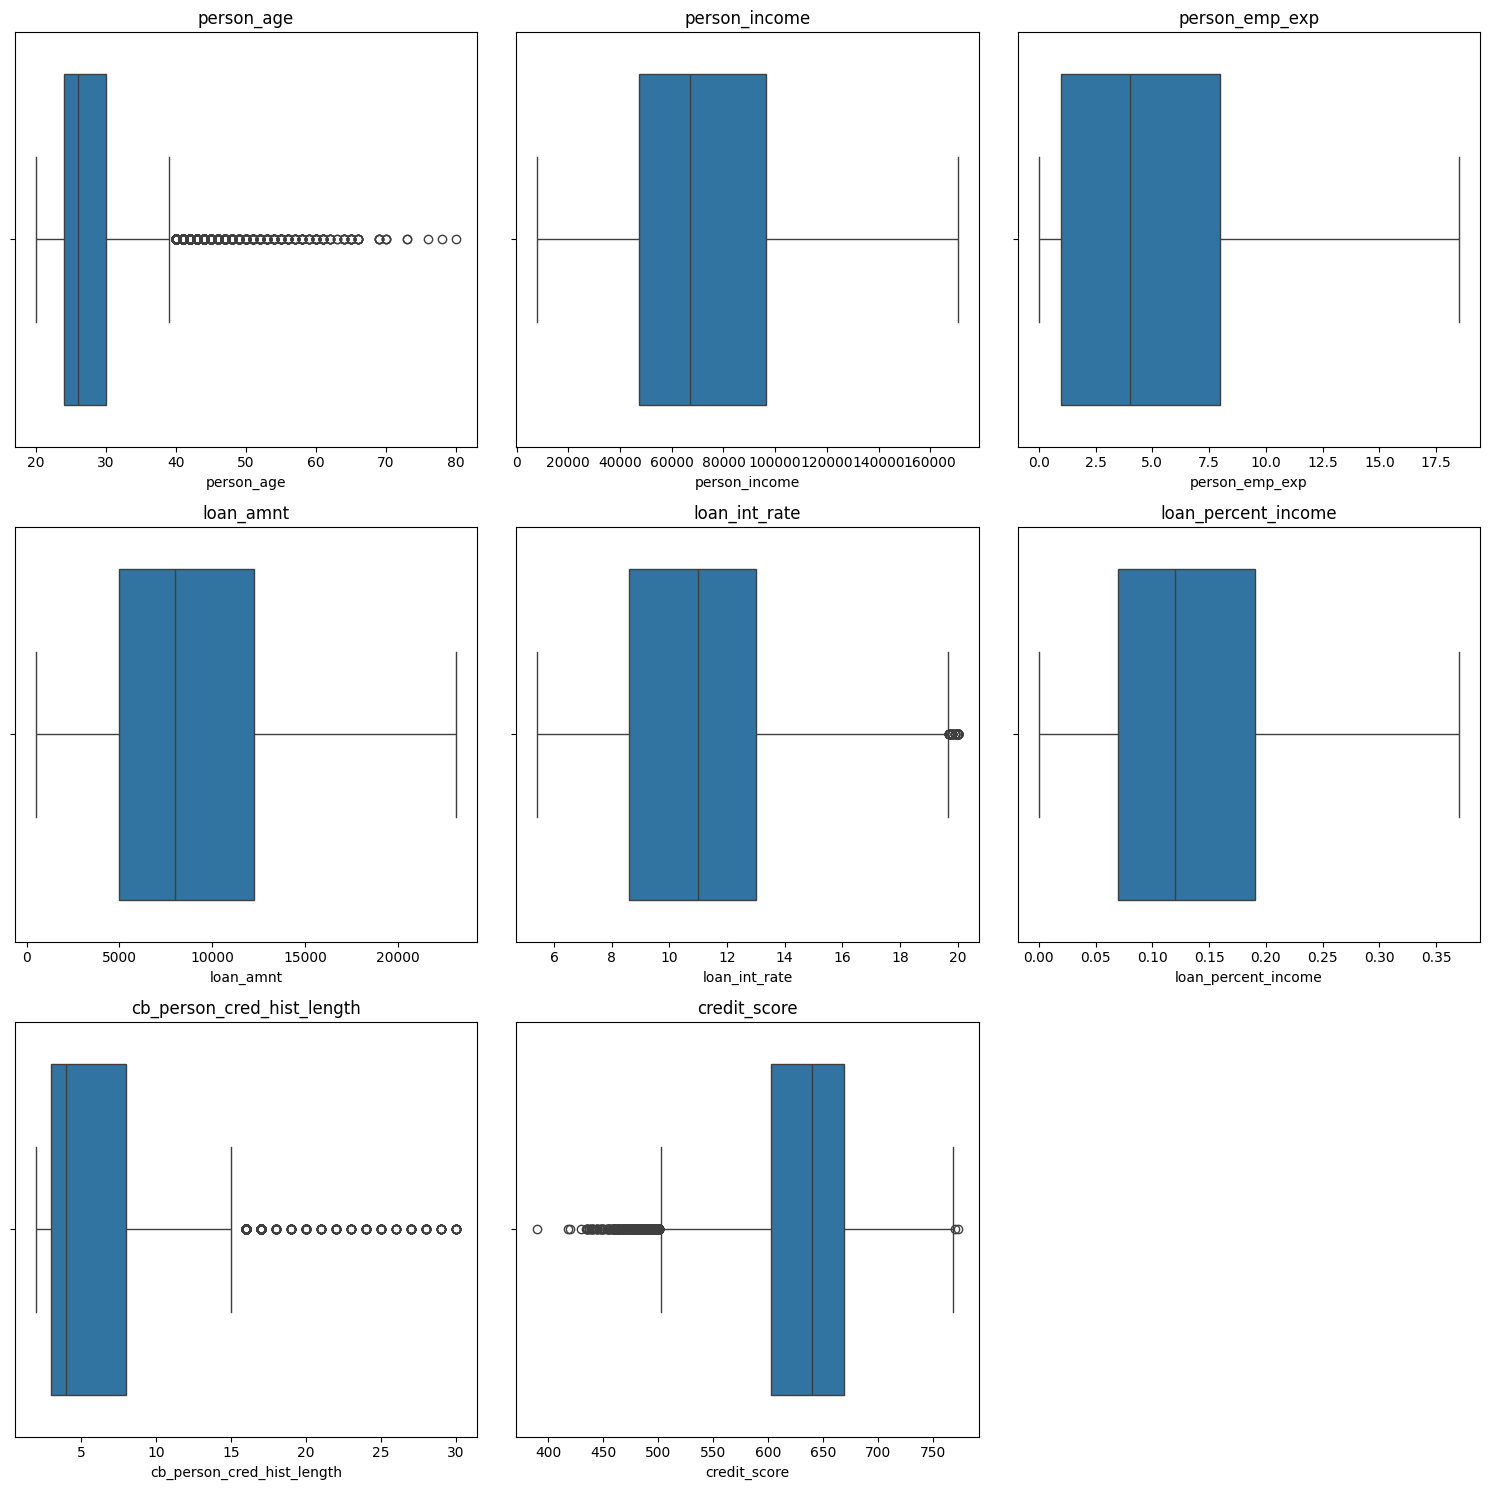

In [19]:
num_plots = len(numerical_features)
num_cols = 3
num_rows = (num_plots + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
  sns.boxplot(x=df_train[col], ax=axes[i])
  axes[i].set_title(col)

for j in range(i+1, num_rows*num_cols):
  axes[j].axis('off')

plt.tight_layout()
plt.show()

In [20]:
df_train.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000
mean,27.7488,75933.8211,5.1679,9437.2741,11.0143,0.1389,5.8598,632.5975,0.2223
std,5.8931,38419.7027,5.1377,5835.5684,2.9740,0.0841,3.8658,50.2147,0.4158
min,20.0000,8000.0000,0.0000,500.0000,5.4200,0.0000,2.0000,390.0000,0.0000
25%,24.0000,47293.0000,1.0000,5000.0000,8.5900,0.0700,3.0000,602.0000,0.0000
50%,26.0000,67098.0000,4.0000,8000.0000,11.0100,0.1200,4.0000,640.0000,0.0000
75%,30.0000,96593.5000,8.0000,12250.0000,13.0200,0.1900,8.0000,669.0000,0.0000
max,80.0000,170544.2500,18.5000,23125.0000,20.0000,0.3700,30.0000,772.0000,1.0000


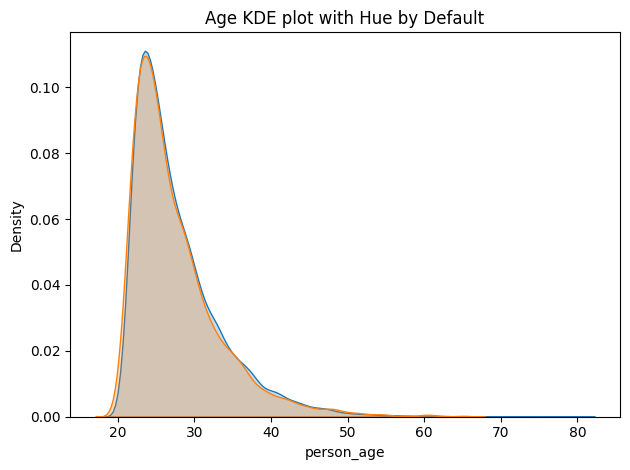

In [21]:
sns.kdeplot(df_train[df_train.loan_status == 0]['person_age'], fill=True, label='Not_Approved')
sns.kdeplot(df_train[df_train.loan_status == 1]['person_age'], fill=True, label='Approved')
plt.title(f"Age KDE plot with Hue by Default")
plt.tight_layout()
plt.show()

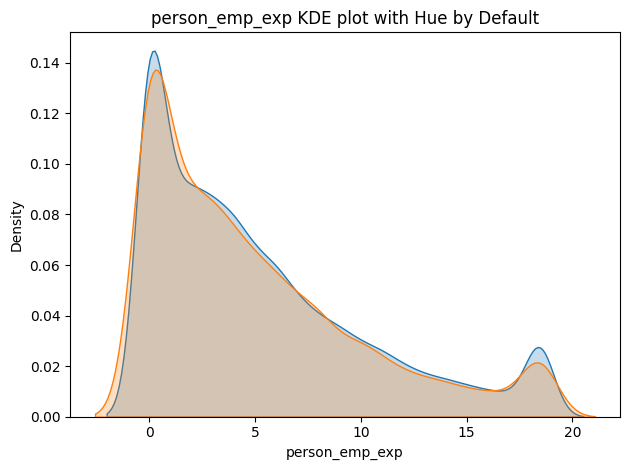

In [22]:
sns.kdeplot(df_train[df_train.loan_status == 0]['person_emp_exp'], fill=True, label='Not_Approved')
sns.kdeplot(df_train[df_train.loan_status == 1]['person_emp_exp'], fill=True, label='Approved')
plt.title(f"person_emp_exp KDE plot with Hue by Default")
plt.tight_layout()
plt.show()

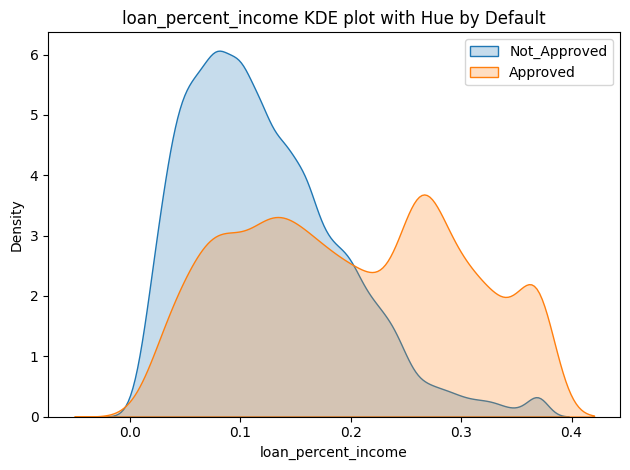

In [23]:
sns.kdeplot(df_train[df_train.loan_status == 0]['loan_percent_income'], fill=True, label='Not_Approved')
sns.kdeplot(df_train[df_train.loan_status == 1]['loan_percent_income'], fill=True, label='Approved')
plt.title(f"loan_percent_income KDE plot with Hue by Default")
plt.tight_layout()
plt.legend()
plt.show()

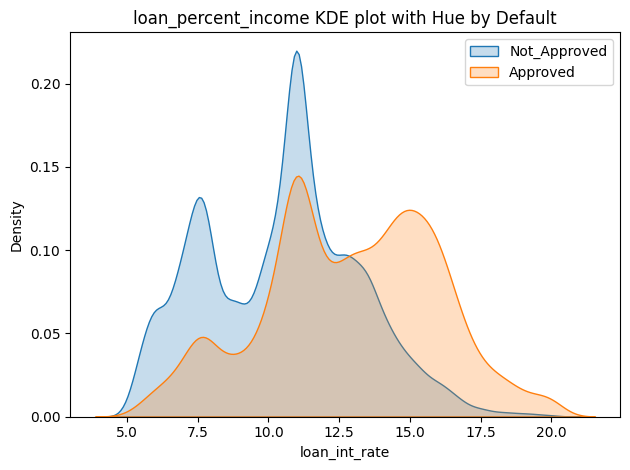

In [24]:
sns.kdeplot(df_train[df_train.loan_status == 0]['loan_int_rate'], fill=True, label='Not_Approved')
sns.kdeplot(df_train[df_train.loan_status == 1]['loan_int_rate'], fill=True, label='Approved')
plt.title(f"loan_percent_income KDE plot with Hue by Default")
plt.tight_layout()
plt.legend()
plt.show()

In [25]:
df_train.head(2)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
12863,26.0000,female,Associate,102675.0000,5.0000,MORTGAGE,6000.0000,EDUCATION,9.8800,0.0600,3.0000,654,No,0
12903,24.0000,male,Bachelor,84036.0000,0.0000,RENT,12000.0000,DEBTCONSOLIDATION,10.2000,0.1400,4.0000,613,No,1


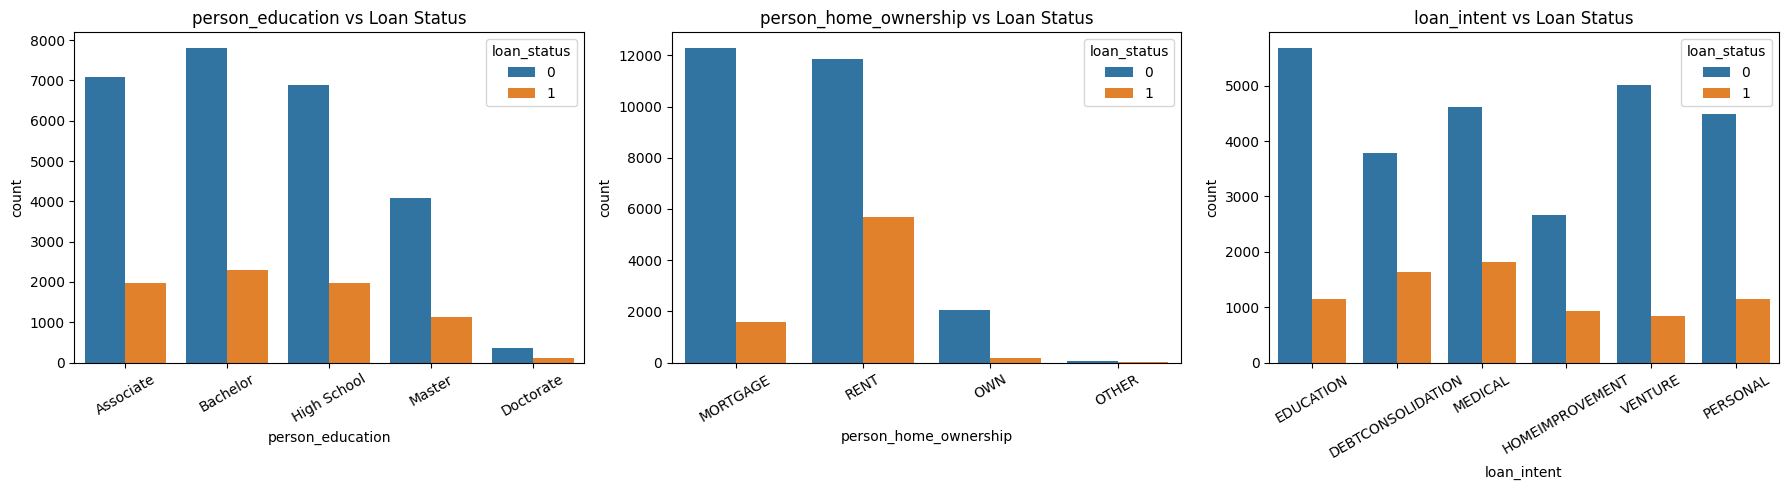

In [26]:
categorical_features = [
    'person_education',
    'person_home_ownership',
    'loan_intent'
]

plt.figure(figsize=(18, 5))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(1, 3, i)
    sns.countplot(
        data=df_train,
        x=col,
        hue='loan_status'
    )
    plt.title(f'{col} vs Loan Status')
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


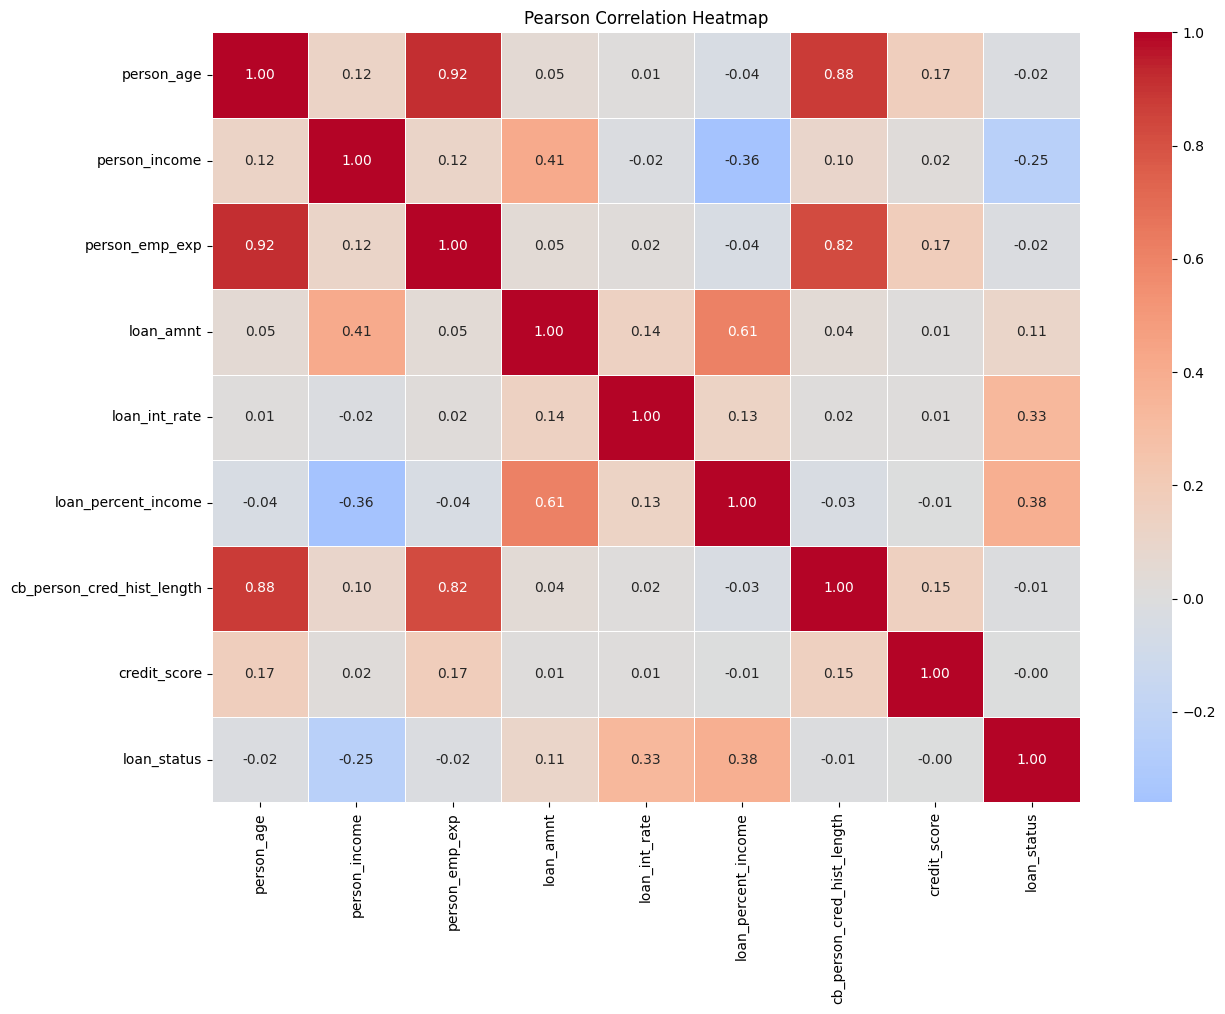

In [27]:
num_df = df_train.select_dtypes(include=['int64', 'float64'])
corr_matrix = num_df.corr(method='pearson')
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")
plt.show()

# Feature Engineering...

In [28]:
education_order = {
    'High School': 1,
    'Associate': 2,
    'Bachelor': 3,
    'Master': 4,
    'Doctorate': 5
}

df_train['person_education_ord'] = df_train['person_education'].map(education_order)
df_test['person_education_ord'] = df_test['person_education'].map(education_order)

In [29]:
df_train.drop(columns='person_education', inplace=True)
df_test.drop(columns='person_education', inplace=True)

In [30]:
df_train['is_renter'] = (df_train['person_home_ownership'] == 'RENT').astype(int)

In [31]:
df_test['is_renter'] = (df_test['person_home_ownership'] == 'RENT').astype(int)

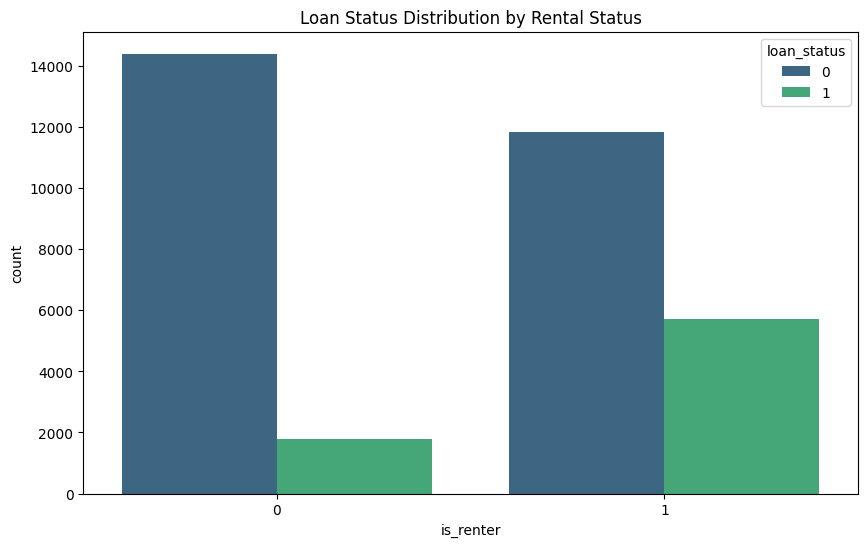

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_train, x='is_renter', hue='loan_status', palette='viridis')
plt.title('Loan Status Distribution by Rental Status')
plt.show()

1.   Younger but with stable income
2.   Applying for smaller, safer loans
3.   Better credit behavior despite not owning property

In [33]:
df_train['loan_intent'].unique()

array(['EDUCATION', 'DEBTCONSOLIDATION', 'MEDICAL', 'HOMEIMPROVEMENT',
       'VENTURE', 'PERSONAL'], dtype=object)

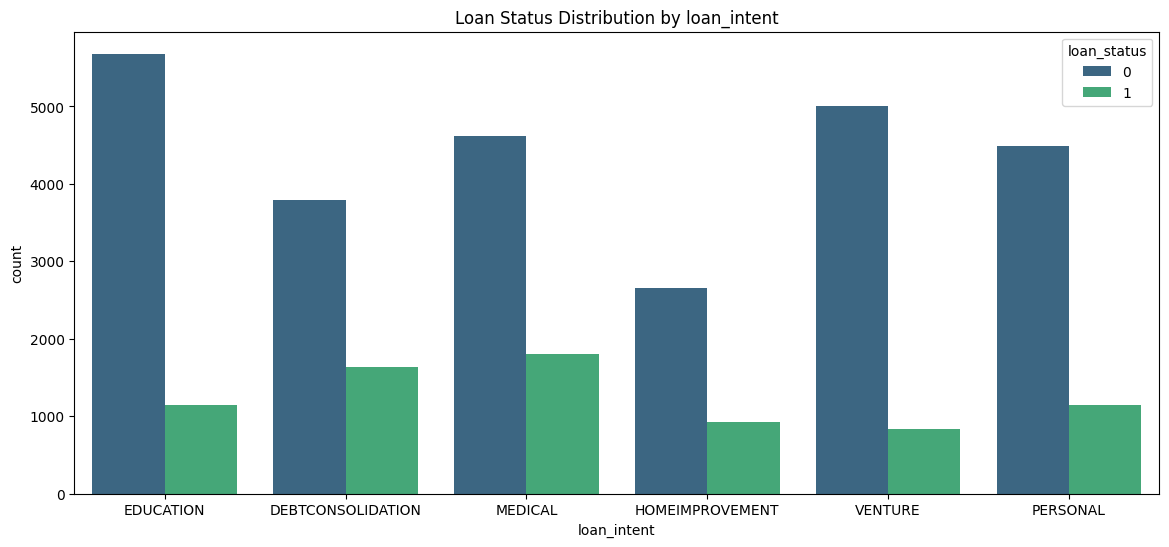

In [34]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df_train, x='loan_intent', hue='loan_status', palette='viridis')
plt.title('Loan Status Distribution by loan_intent')
plt.show()

In [35]:
high_risk_intents = ['DEBTCONSOLIDATION', 'MEDICAL']
df_train['is_high_risk_intent'] = df_train['loan_intent'].isin(high_risk_intents).astype(int)
df_test['is_high_risk_intent'] = df_test['loan_intent'].isin(high_risk_intents).astype(int)

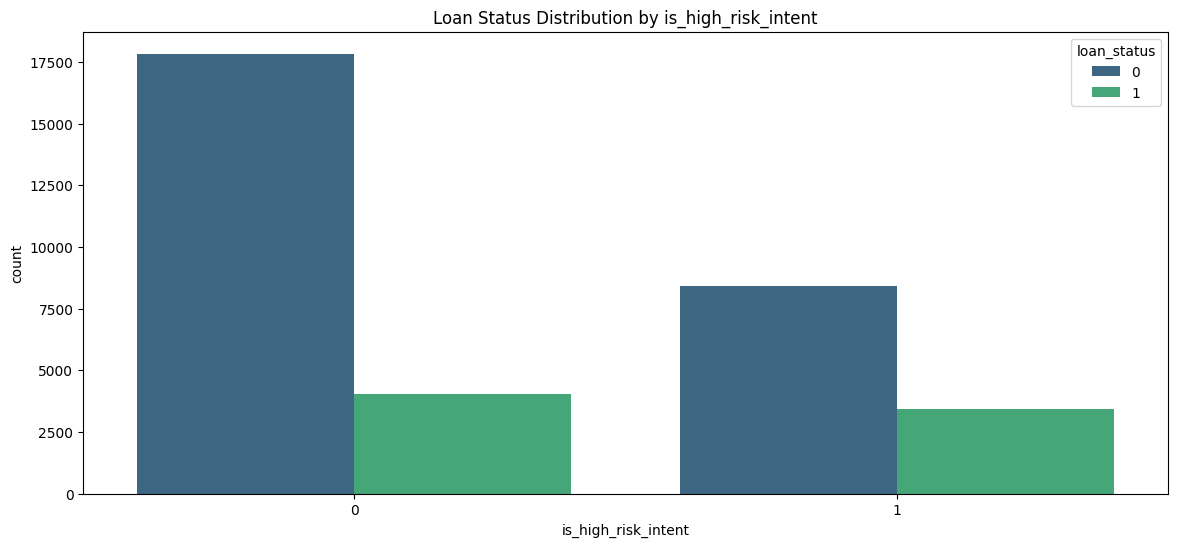

In [36]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df_train, x='is_high_risk_intent', hue='loan_status', palette='viridis')
plt.title('Loan Status Distribution by is_high_risk_intent')
plt.show()

In [37]:
df_train['interest_to_income_ratio'] = (
    df_train['loan_amnt'] * df_train['loan_int_rate']
) / df_train['person_income']

df_test['interest_to_income_ratio'] = (
    df_test['loan_amnt'] * df_test['loan_int_rate']
) / df_test['person_income']

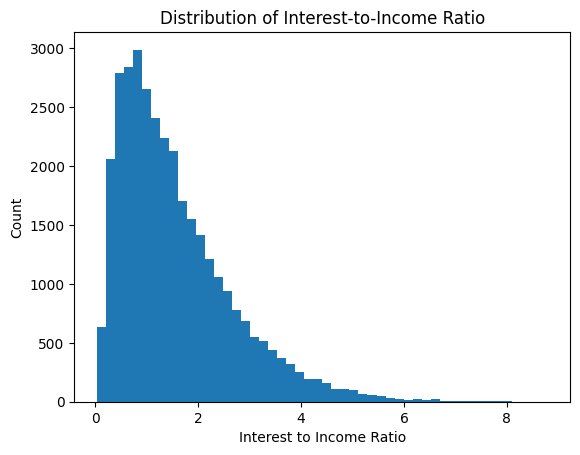

In [38]:
plt.figure()
plt.hist(df_train['interest_to_income_ratio'], bins=50)
plt.xlabel('Interest to Income Ratio')
plt.ylabel('Count')
plt.title('Distribution of Interest-to-Income Ratio')
plt.show()

Most borrowers have manageable interest burden, but a small group has very high repayment stress.

<Figure size 640x480 with 0 Axes>

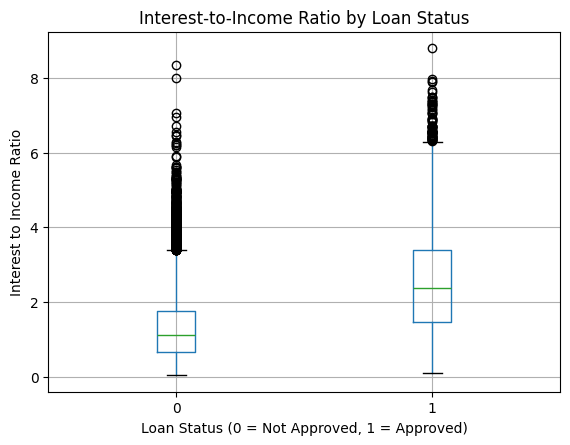

In [39]:
plt.figure()
df_train.boxplot(
    column='interest_to_income_ratio',
    by='loan_status'
)
plt.xlabel('Loan Status (0 = Not Approved, 1 = Approved)')
plt.ylabel('Interest to Income Ratio')
plt.title('Interest-to-Income Ratio by Loan Status')
plt.suptitle('')
plt.show()

Borrowers who were approved actually carry more interest burden than those rejected.
Lenders are accepting higher-risk profiles in approved loans.

In [40]:
cap = df_train['interest_to_income_ratio'].quantile(0.99)
cap

np.float64(5.122441660586534)

Doing clipping for "cap" increaste VIF -> 18.7

In [41]:
df_train['interest_to_income_ratio'] = df_train['interest_to_income_ratio'].clip(upper=2)
df_test['interest_to_income_ratio'] = df_test['interest_to_income_ratio'].clip(upper=2)

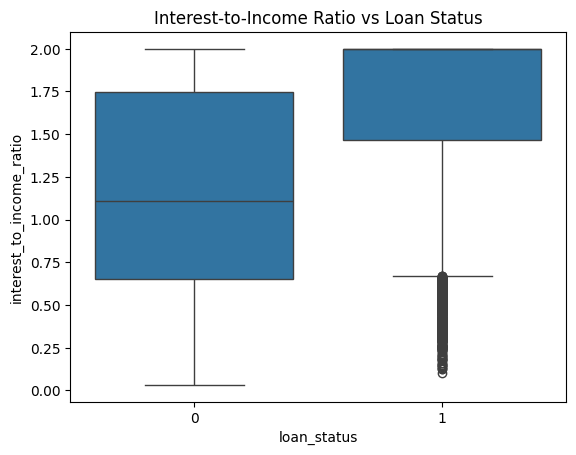

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_train,
    x='loan_status',
    y='interest_to_income_ratio'
)
plt.title("Interest-to-Income Ratio vs Loan Status")
plt.show()

In [43]:
int_cols = df_train.select_dtypes(include=['int64', 'float64']).columns.drop('loan_status')

In [44]:
df_train[int_cols] = df_train[int_cols].astype('float64')

In [45]:
X_train = df_train.drop('loan_status', axis='columns')
y_train = df_train['loan_status']

from sklearn.preprocessing import StandardScaler

cols_to_scale = int_cols

scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_train.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_education_ord,is_renter,is_high_risk_intent,interest_to_income_ratio
count,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000,33743.0000
mean,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-1.3149,-1.7682,-1.0059,-1.5315,-1.8811,-1.6510,-0.9985,-4.8313,-1.2905,-1.0408,-0.7358,-2.0429
25%,-0.6361,-0.7455,-0.8113,-0.7604,-0.8152,-0.8189,-0.7398,-0.6093,-1.2905,-1.0408,-0.7358,-0.8882
50%,-0.2968,-0.2300,-0.2273,-0.2463,-0.0015,-0.2245,-0.4811,0.1474,-0.3609,0.9608,-0.7358,0.0208
75%,0.3820,0.5377,0.5512,0.4820,0.6744,0.6076,0.5536,0.7249,0.5687,0.9608,1.3591,1.1693
max,8.8666,2.4626,2.5950,2.3456,3.0215,2.7473,6.2447,2.7762,2.4278,0.9608,1.3591,1.1693


In [46]:
X_test = df_test.drop('loan_status', axis='columns')
y_test = df_test['loan_status']

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_education_ord,is_renter,is_high_risk_intent,interest_to_income_ratio
count,11248.0000,11248.0000,11248.0000,11248.0000,11248.0000,11248.0000,11248.0000,11248.0000,11248.0000,11248.0000,11248.0000,11248.0000
mean,-0.0021,0.0900,0.0443,0.0122,-0.0105,0.0082,0.0061,-0.0015,-0.0179,0.0079,-0.0206,-0.0236
std,1.0018,1.6982,1.1528,1.0824,1.0067,1.0422,1.0096,1.0143,1.0073,0.9997,0.9934,1.0156
min,-1.3149,-1.7682,-1.0059,-1.5315,-1.8811,-1.6510,-0.9985,-4.2537,-1.2905,-1.0408,-0.7358,-2.0814
25%,-0.6361,-0.7546,-0.8113,-0.7604,-0.8328,-0.8189,-0.7398,-0.6293,-1.2905,-1.0408,-0.7358,-0.9441
50%,-0.2968,-0.2354,-0.2273,-0.2463,-0.0015,-0.2245,-0.4811,0.1474,-0.3609,0.9608,-0.7358,-0.0284
75%,0.3820,0.4840,0.5512,0.4392,0.6643,0.6076,0.5536,0.7449,0.5687,0.9608,1.3591,1.1693
max,7.6787,53.7026,8.7262,4.3806,3.0215,5.0058,6.2447,3.0151,2.4278,0.9608,1.3591,1.1693


In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

In [48]:
calculate_vif(X_train[cols_to_scale])

,Column,VIF
0,person_age,8.9287
1,person_income,4.9612
2,person_emp_exp,6.2514
3,loan_amnt,7.0338
4,loan_int_rate,1.7880
5,loan_percent_income,6.7895
6,cb_person_cred_hist_length,4.4105
7,credit_score,1.0817
8,person_education_ord,1.0484
9,is_renter,1.1546


In [49]:
features_to_drop = ['person_age']
X_train_1 = X_train.drop(features_to_drop, axis='columns')
numeric_columns = X_train_1.select_dtypes(include=['int64', 'float64']).columns

In [50]:
vif_df = calculate_vif(X_train_1[numeric_columns])
vif_df

,Column,VIF
0,person_income,4.9596
1,person_emp_exp,3.1005
2,loan_amnt,7.0335
3,loan_int_rate,1.7878
4,loan_percent_income,6.7895
5,cb_person_cred_hist_length,3.0660
6,credit_score,1.0811
7,person_education_ord,1.0483
8,is_renter,1.1545
9,is_high_risk_intent,1.0081


In [51]:
selected_numeric_features_vif = vif_df.Column.values
selected_numeric_features_vif

array(['person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate',
       'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'person_education_ord', 'is_renter',
       'is_high_risk_intent', 'interest_to_income_ratio'], dtype=object)

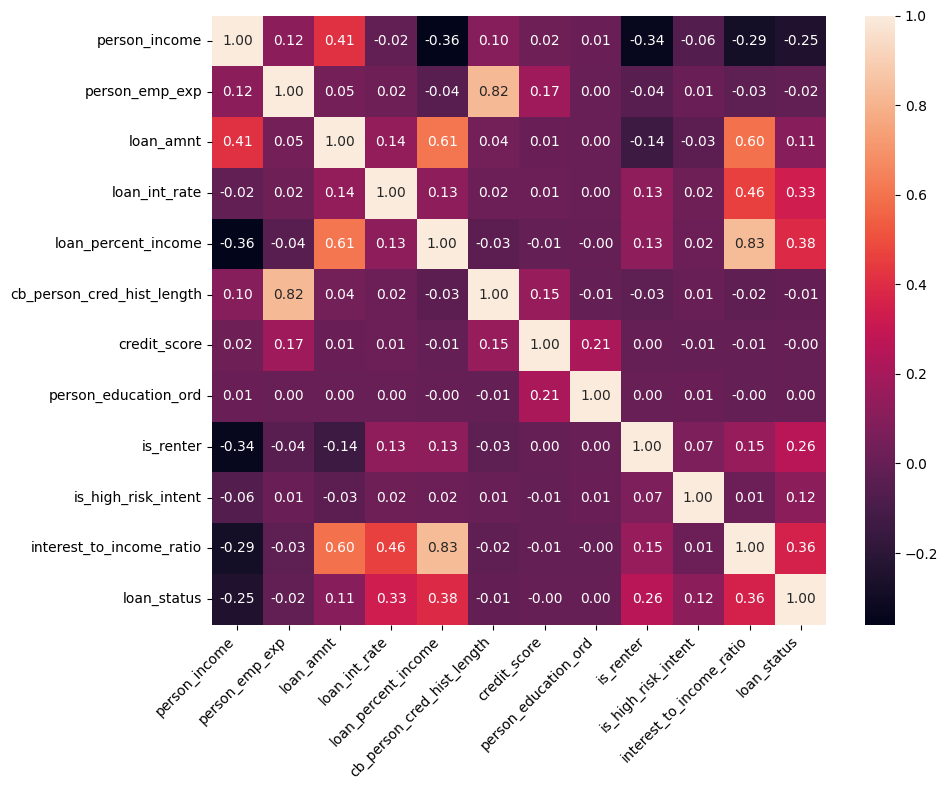

In [52]:
plt.figure(figsize=(10,8))
cm = df_train[numeric_columns.append(pd.Index(['loan_status']))].corr()
sns.heatmap(cm, annot=True, fmt='0.2f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [53]:
def calculate_woe_iv(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad'] = grouped['total'] - grouped['good']

    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()

    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad

    grouped['woe'] = np.log(grouped['good_pct']/grouped['bad_pct'])
    grouped['iv'] = (grouped['good_pct']-grouped['bad_pct'])*grouped['woe']

    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)

    total_iv = grouped['iv'].sum()

    return grouped, total_iv

grouped, total_iv = calculate_woe_iv(pd.concat([X_train_1, y_train], axis=1), 'is_high_risk_intent', 'loan_status')
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
is_high_risk_intent,,,,,,,
-0.7358,21891,4056,17835,0.5408,0.6796,-0.2285,0.0317
1.3591,11852,3444,8408,0.4592,0.3204,0.3599,0.0500


In [54]:
iv_values = {}

for feature in X_train_1.columns:
    if X_train_1[feature].dtype == 'object':
        _, iv = calculate_woe_iv(pd.concat([X_train_1, y_train], axis=1), feature, 'loan_status')
    else:
        X_binned = pd.cut(X_train_1[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X_train_1, y_train], axis=1), feature, 'loan_status')
    iv_values[feature] = iv

iv_values

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = geta

{'person_gender': np.float64(0.00021899266124898742),
 'person_income': np.float64(0.22759545193405673),
 'person_emp_exp': np.float64(0.007280595273652641),
 'person_home_ownership': np.float64(0.43113140096935354),
 'loan_amnt': np.float64(0.21315948208570662),
 'loan_intent': np.float64(0.12193008500892599),
 'loan_int_rate': np.float64(0.8483841264745394),
 'loan_percent_income': np.float64(0.9459192006848243),
 'cb_person_cred_hist_length': np.float64(0.005430672520411573),
 'credit_score': np.float64(0.046293035368783424),
 'previous_loan_defaults_on_file': np.float64(0.6867222217321732),
 'person_education_ord': np.float64(0.0009429720692048543),
 'is_renter': np.float64(0.4164119799597673),
 'is_high_risk_intent': np.float64(0.0816778390541773),
 'interest_to_income_ratio': np.float64(0.5050304812057359)}

In [55]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
7,loan_percent_income,0.946
6,loan_int_rate,0.848
10,previous_loan_defaults_on_file,0.687
14,interest_to_income_ratio,0.505
3,person_home_ownership,0.431
12,is_renter,0.416
1,person_income,0.228
4,loan_amnt,0.213
5,loan_intent,0.122
13,is_high_risk_intent,0.082


In [56]:
# Selected feature that has IV > 0.02
selected_features_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_features_iv

['person_income',
 'person_home_ownership',
 'loan_amnt',
 'loan_intent',
 'loan_int_rate',
 'loan_percent_income',
 'credit_score',
 'previous_loan_defaults_on_file',
 'is_renter',
 'is_high_risk_intent',
 'interest_to_income_ratio']

In [57]:
# X_test = X_test.drop(features_to_drop, axis='columns')

In [58]:
X_train_1.shape, X_test.shape

((33743, 15), (11248, 16))

In [59]:
X_train_reduced = X_train_1[selected_features_iv]
X_test_reduced = X_test[selected_features_iv]

In [60]:
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True)
X_train_encoded.head(3)

,person_income,loan_amnt,loan_int_rate,loan_percent_income,credit_score,is_renter,is_high_risk_intent,interest_to_income_ratio,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
12863,0.696,-0.589,-0.381,-0.938,0.426,-1.041,-0.736,-1.154,False,False,False,True,False,False,False,False,False
12903,0.211,0.439,-0.274,0.013,-0.390,0.961,1.359,0.282,False,False,True,False,False,False,False,False,False
8164,-0.200,1.365,-1.689,1.321,0.725,-1.041,1.359,0.397,False,False,False,False,False,True,False,False,True


In [61]:
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True)
X_test_encoded.head(3)

,person_income,loan_amnt,loan_int_rate,loan_percent_income,credit_score,is_renter,is_high_risk_intent,interest_to_income_ratio,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
2799,-0.113,0.439,-0.217,0.370,0.526,0.961,-0.736,0.741,False,False,True,False,False,False,True,False,False
23680,0.066,0.096,0.328,-0.106,0.486,-1.041,-0.736,0.399,False,True,False,False,False,False,False,True,False
9085,-0.070,-0.760,-1.303,-0.819,-0.510,-1.041,1.359,-1.301,False,False,False,False,False,True,False,False,False


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.93      0.95      0.94      8748
           1       0.80      0.74      0.77      2500

    accuracy                           0.90     11248
   macro avg       0.87      0.85      0.86     11248
weighted avg       0.90      0.90      0.90     11248



In [63]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.94      0.97      0.96      8748
           1       0.89      0.79      0.84      2500

    accuracy                           0.93     11248
   macro avg       0.92      0.88      0.90     11248
weighted avg       0.93      0.93      0.93     11248



In [64]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_encoded, y_train)
y_train_smt.value_counts()

,count
loan_status,
0,25943
1,25943


In [65]:
model = XGBClassifier()
model.fit(X_train_smt, y_train_smt)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      8748
           1       0.79      0.87      0.83      2500

    accuracy                           0.92     11248
   macro avg       0.88      0.90      0.89     11248
weighted avg       0.92      0.92      0.92     11248



In [66]:
!pip install shap

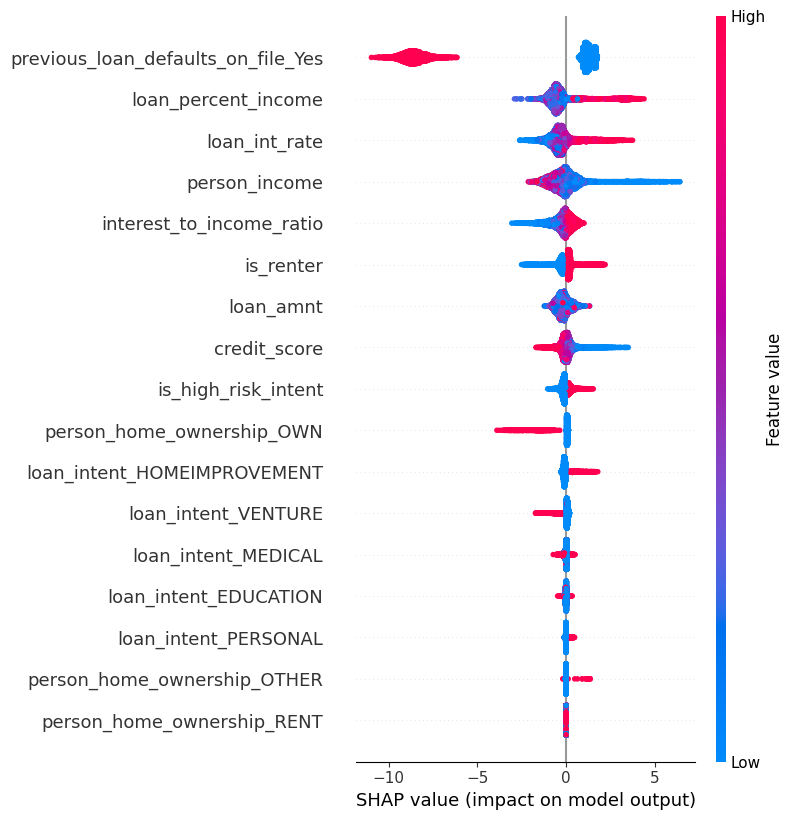

In [67]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_encoded)
shap.summary_plot(shap_values, X_test_encoded)

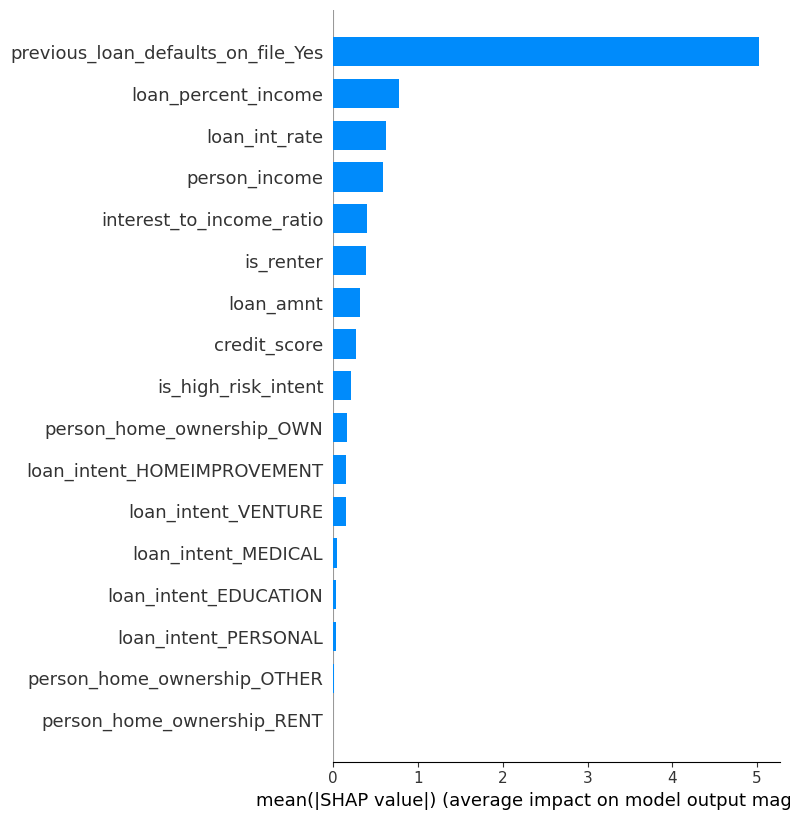

In [68]:
shap.summary_plot(shap_values, X_test_encoded, plot_type="bar")

In [96]:
model = XGBClassifier(
    max_depth=5,
    learning_rate=0.3,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [97]:
model.fit(X_train_smt, y_train_smt)
y_pred = model.predict(X_test_encoded)
y_prob = model.predict_proba(X_test_encoded)[:, 1]

In [98]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      8748
           1       0.81      0.86      0.83      2500

    accuracy                           0.92     11248
   macro avg       0.88      0.90      0.89     11248
weighted avg       0.93      0.92      0.92     11248



Instead of SMOTE, I used threshold tuning to control class imbalance. SMOTE introduces synthetic and potentially unrealistic financial profiles, which can harm generalization in credit models. By adjusting the probability threshold, I preserved real data distributions while optimizing precision–recall trade-offs based on business risk.

# Randomized Search CV

In [72]:
from sklearn.model_selection import RandomizedSearchCV
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
param_dist = {
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "n_estimators": [200, 300, 400, 500],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8],
    "reg_alpha": [0, 0.1, 0.5, 1],
    "reg_lambda": [1, 2, 5, 10]
}
random_searching = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_searching.fit(X_train_smt, y_train_smt)
best_model_with_smote = random_searching.best_estimator_

print("Best Parameters:")
print(random_searching.best_params_)

print("Best CV ROC-AUC:")
print(random_searching.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 400, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Best CV ROC-AUC:
0.9908693486908184


In [73]:
y_pred = best_model_with_smote.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      8748
           1       0.80      0.87      0.83      2500

    accuracy                           0.92     11248
   macro avg       0.88      0.90      0.89     11248
weighted avg       0.93      0.92      0.92     11248



ROC AUC: 0.9760485596707819


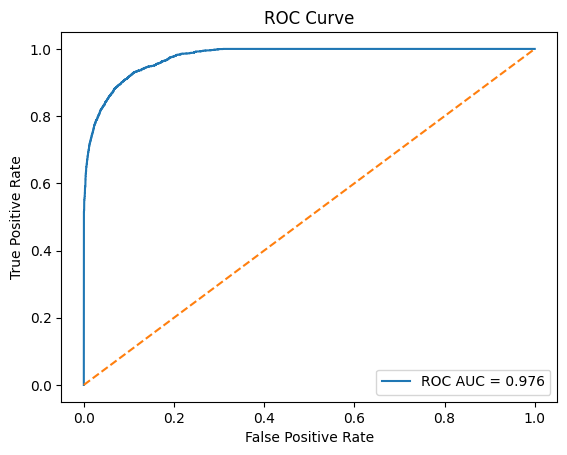

In [74]:
from sklearn.metrics import roc_auc_score, roc_curve

y_test_prob = best_model_with_smote.predict_proba(X_test_encoded)[:,1]

roc_auc = roc_auc_score(y_test, y_test_prob)
print("ROC AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.plot(fpr, tpr, label="ROC AUC = %0.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Using LightGBM Model

In [75]:
from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(
    objective="binary",
    random_state=42
)

model_lgbm.fit(X_train_smt, y_train_smt)

y_pred = model_lgbm.predict(X_test_encoded)

print(classification_report(y_test, y_pred))

[LightGBM] [Info] Number of positive: 25943, number of negative: 25943
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005321 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 51886, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      8748
           1       0.79      0.85      0.82      2500

    accuracy                           0.92     11248
   macro avg       0.87      0.89      0.88     11248
weighted avg       0.92      0.92      0.92     11248



In [76]:
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# Base model
lgbm_base = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
param_dist = {
    "n_estimators": [200,300,400,500],
    "learning_rate": [0.01,0.03,0.05,0.1],
    "num_leaves": [20,31,40,50,60],
    "max_depth": [-1,5,10,15],
    "subsample": [0.6,0.7,0.8,0.9],
    "colsample_bytree": [0.6,0.7,0.8],
    "min_child_samples": [10,20,30,40]
}

# Randomized Search
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train model
random_search_lgbm.fit(X_train_smt, y_train_smt)

# Best model
best_lgb_model = random_search_lgbm.best_estimator_

print("Best Parameters:", random_search_lgbm.best_params_)
print("Best CV ROC-AUC:", random_search_lgbm.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Info] Number of positive: 25943, number of negative: 25943
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008262 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 51886, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best Parameters: {'subsample': 0.9, 'num_leaves': 50, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
Best CV ROC-AUC: 0.9929801018396572


In [77]:
lgbm_y_pred = best_lgb_model.predict(X_test_encoded)

# Classification report
print(classification_report(y_test, lgbm_y_pred))

# ROC-AUC
y_prob = best_lgb_model.predict_proba(X_test_encoded)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)

print("Test ROC-AUC:", roc_auc)

              precision    recall  f1-score   support

           0       0.96      0.96      0.96      8748
           1       0.85      0.85      0.85      2500

    accuracy                           0.93     11248
   macro avg       0.90      0.90      0.90     11248
weighted avg       0.93      0.93      0.93     11248

Test ROC-AUC: 0.9773399634202103


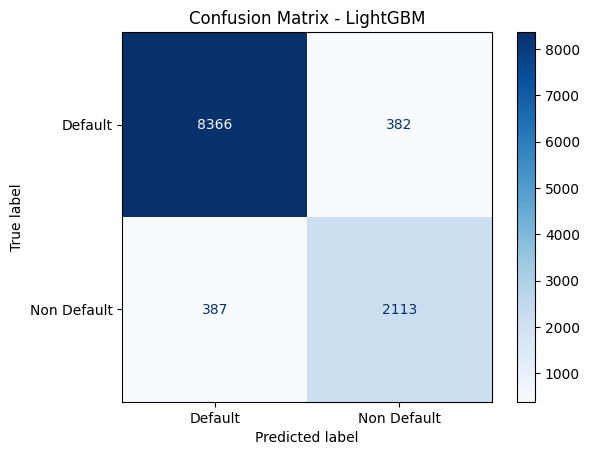

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lgb = confusion_matrix(y_test, lgbm_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgb,
    display_labels=["Default", "Non Default"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - LightGBM")
plt.show()

ROC AUC: 0.9773399634202103


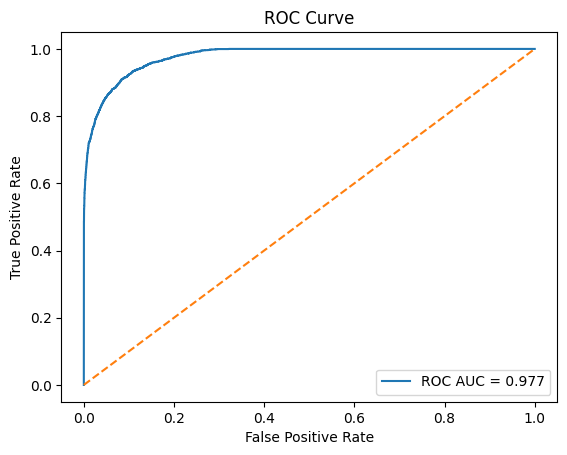

In [79]:
from sklearn.metrics import roc_auc_score, roc_curve

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC AUC = %0.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# RandomForest

In [99]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smt, y_train_smt)
rf_y_pred = rf_model.predict(X_test_encoded)

print(classification_report(y_test, rf_y_pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      8748
           1       0.79      0.85      0.82      2500

    accuracy                           0.92     11248
   macro avg       0.87      0.89      0.88     11248
weighted avg       0.92      0.92      0.92     11248



In [81]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# Base model
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Smaller hyperparameter search space (FASTER)
param_dist_rf = {
    "n_estimators": [100,150,200],
    "max_depth": [10,15,20],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2],
    "max_features": ["sqrt","log2"]
}

# Randomized Search (reduced computation)
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=5,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train model
random_search_rf.fit(X_train_smt, y_train_smt)

# Best model
best_rf_model = random_search_rf.best_estimator_

print("Best Parameters:", random_search_rf.best_params_)
print("Best CV ROC-AUC:", random_search_rf.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best CV ROC-AUC: 0.9911406398156307


In [82]:
# Predictions
y_pred_rf = best_rf_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      8748
           1       0.78      0.85      0.82      2500

    accuracy                           0.92     11248
   macro avg       0.87      0.89      0.88     11248
weighted avg       0.92      0.92      0.92     11248



ROC AUC: 0.971890877914952


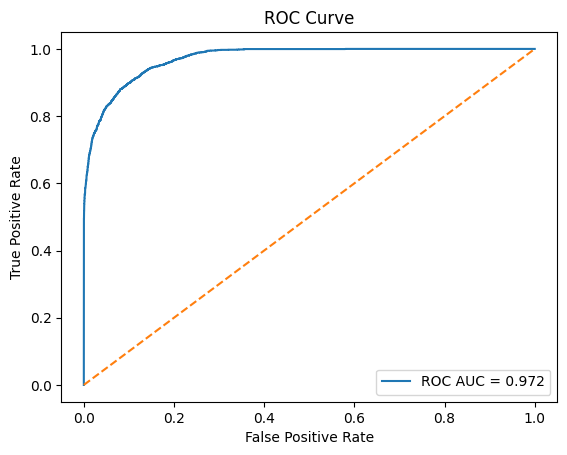

In [83]:
y_prob_rf = best_rf_model.predict_proba(X_test_encoded)[:,1]

roc_auc = roc_auc_score(y_test, y_prob_rf)
print("ROC AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.plot(fpr, tpr, label="ROC AUC = %0.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

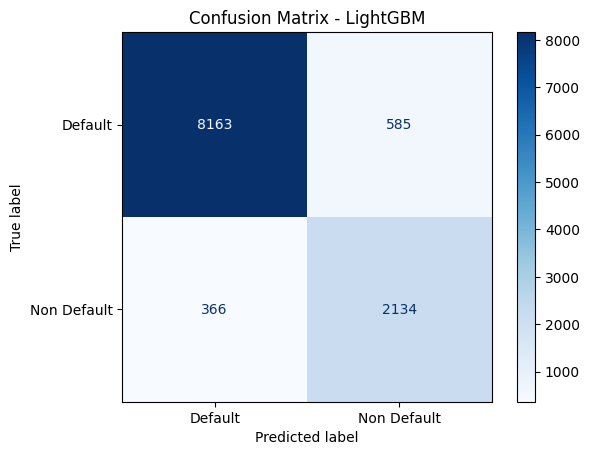

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lgb = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lgb,
    display_labels=["Default", "Non Default"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - LightGBM")
plt.show()

In [85]:
model_logistic = LogisticRegression()
model_logistic.fit(X_train_smt, y_train_smt)

y_pred = model_logistic.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      8748
           1       0.63      0.92      0.75      2500

    accuracy                           0.86     11248
   macro avg       0.80      0.88      0.83     11248
weighted avg       0.90      0.86      0.87     11248



In [86]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# Base model
logistic_base = LogisticRegression(max_iter=1000)

# Hyperparameter search space
param_dist_log = {
    "C": np.logspace(-3, 3, 20),   # regularization strength
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

# Randomized Search
random_search_log = RandomizedSearchCV(
    estimator=logistic_base,
    param_distributions=param_dist_log,
    n_iter=10,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train model
random_search_log.fit(X_train_smt, y_train_smt)

# Best model
best_log_model = random_search_log.best_estimator_

print("Best Parameters:", random_search_log.best_params_)
print("Best CV ROC-AUC:", random_search_log.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': np.float64(1000.0)}
Best CV ROC-AUC: 0.9582766536760401


In [87]:
# Predictions
y_pred_log = best_log_model.predict(X_test_encoded)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      8748
           1       0.64      0.92      0.75      2500

    accuracy                           0.86     11248
   macro avg       0.80      0.88      0.83     11248
weighted avg       0.90      0.86      0.87     11248



ROC AUC: 0.9575207590306355


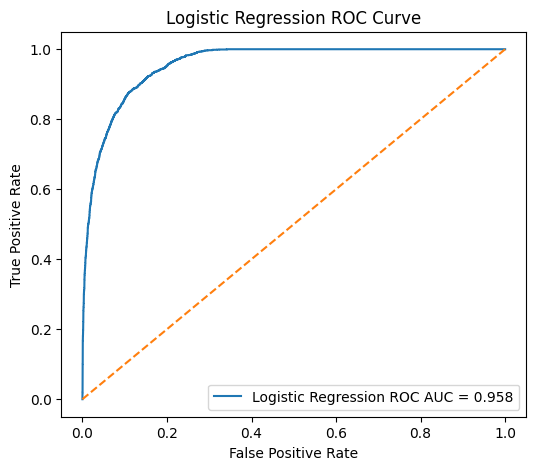

In [88]:
y_prob_log = best_log_model.predict_proba(X_test_encoded)[:,1]

roc_auc_log = roc_auc_score(y_test, y_prob_log)
print("ROC AUC:", roc_auc_log)

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression ROC AUC = %0.3f" % roc_auc_log)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

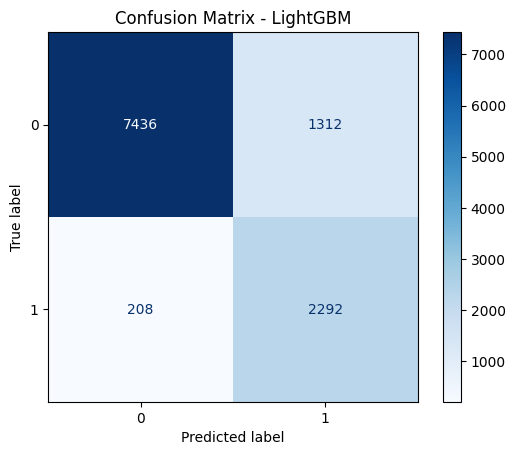

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - LightGBM")
plt.show()

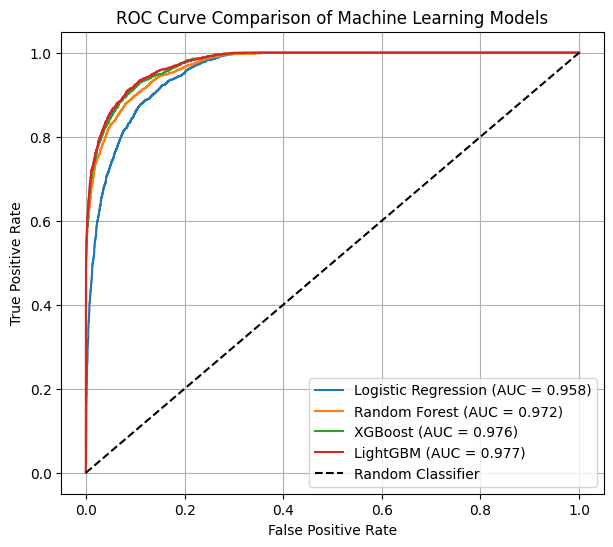

In [91]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Logistic Regression
y_prob_log = best_log_model.predict_proba(X_test_encoded)[:,1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
roc_auc_log = roc_auc_score(y_test, y_prob_log)

# Random Forest
y_prob_rf = best_rf_model.predict_proba(X_test_encoded)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# XGBoost
y_prob_xgb = best_model_with_smote.predict_proba(X_test_encoded)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# LightGBM
y_prob_lgb = best_lgb_model.predict_proba(X_test_encoded)[:,1]
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)
roc_auc_lgb = roc_auc_score(y_test, y_prob_lgb)

# Plot all ROC curves
plt.figure(figsize=(7,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.3f})")
plt.plot(fpr_lgb, tpr_lgb, label=f"LightGBM (AUC = {roc_auc_lgb:.3f})")

# Random baseline
plt.plot([0,1], [0,1], 'k--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [92]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": best_log_model,
    "Random Forest": best_rf_model,
    "XGBoost": best_model_with_smote,
    "LightGBM": best_lgb_model
}

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_smt, y_train_smt,
                             scoring="roc_auc",
                             cv=cv)
    cv_results[name] = scores
    print(name, ":", scores)

Logistic Regression : [0.95614454 0.95834793 0.96021587 0.95974846 0.9570932 ]
Random Forest : [0.99088312 0.99027161 0.99214835 0.99074489 0.99080457]
XGBoost : [0.99144647 0.99045115 0.9919775  0.991425   0.99097587]
[LightGBM] [Info] Number of positive: 20754, number of negative: 20754
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006938 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 41508, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 20755, number of negative: 20754
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006712 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1555
[LightGBM] [Info] Number of data points in the train set: 41509, number of 

In [93]:
from scipy.stats import ttest_rel
from itertools import combinations

alpha = 0.05
num_tests = len(list(combinations(models.keys(),2)))
bonf_alpha = alpha / num_tests

print("Bonferroni corrected alpha:", bonf_alpha)
print()

for m1, m2 in combinations(models.keys(),2):

    scores1 = cv_results[m1]
    scores2 = cv_results[m2]

    t_stat, p_value = ttest_rel(scores1, scores2)

    print(f"{m1} vs {m2}")
    print("t-stat:", t_stat)
    print("p-value:", p_value)

    if p_value < bonf_alpha:
        print("Significant after Bonferroni correction")
    else:
        print("Not statistically significant")

    print()

Bonferroni corrected alpha: 0.008333333333333333

Logistic Regression vs Random Forest
t-stat: -47.98661641632037
p-value: 1.1282736396349391e-06
Significant after Bonferroni correction

Logistic Regression vs XGBoost
t-stat: -46.24082245731854
p-value: 1.3082664072234706e-06
Significant after Bonferroni correction

Logistic Regression vs LightGBM
t-stat: -45.835208561305144
p-value: 1.3551192501410686e-06
Significant after Bonferroni correction

Random Forest vs XGBoost
t-stat: -1.8661866716206519
p-value: 0.1354272441944035
Not statistically significant

Random Forest vs LightGBM
t-stat: -16.78944457723495
p-value: 7.375711980082301e-05
Significant after Bonferroni correction

XGBoost vs LightGBM
t-stat: -16.108796545302553
p-value: 8.686062612091094e-05
Significant after Bonferroni correction



In [94]:
def cohens_d(x, y):
    diff = x - y
    return np.mean(diff) / np.std(diff, ddof=1)

for m1, m2 in combinations(models.keys(),2):

    scores1 = cv_results[m1]
    scores2 = cv_results[m2]

    d = cohens_d(scores1, scores2)

    print(f"Cohen's d ({m1} vs {m2}) :", d)

Cohen's d (Logistic Regression vs Random Forest) : -21.46026726341994
Cohen's d (Logistic Regression vs XGBoost) : -20.679524470012623
Cohen's d (Logistic Regression vs LightGBM) : -20.49812842119173
Cohen's d (Random Forest vs XGBoost) : -0.834584051289571
Cohen's d (Random Forest vs LightGBM) : -7.508467875832512
Cohen's d (XGBoost vs LightGBM) : -7.204072822202057


In [95]:
import scipy.stats as st

for model, scores in cv_results.items():

    mean = np.mean(scores)
    sem = st.sem(scores)

    ci = st.t.interval(
        0.95,
        len(scores)-1,
        loc=mean,
        scale=sem
    )

    print(model)
    print("Mean ROC-AUC:", mean)
    print("95% CI:", ci)
    print()

Logistic Regression
Mean ROC-AUC: 0.9583099959986304
95% CI: (np.float64(0.9561708019375026), np.float64(0.9604491900597583))

Random Forest
Mean ROC-AUC: 0.9909705076220439
95% CI: (np.float64(0.9901009307471992), np.float64(0.9918400844968885))

XGBoost
Mean ROC-AUC: 0.9912551979602368
95% CI: (np.float64(0.9905441761943093), np.float64(0.9919662197261642))

LightGBM
Mean ROC-AUC: 0.9934812499002961
95% CI: (np.float64(0.9929496216233297), np.float64(0.9940128781772625))



In [100]:
import sys
import sklearn
import xgboost
import lightgbm
import pandas as pd
import numpy as np
import imblearn
import shap

print("Python version:", sys.version)
print("scikit-learn version:", sklearn.__version__)
print("XGBoost version:", xgboost.__version__)
print("LightGBM version:", lightgbm.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("imbalanced-learn version:", imblearn.__version__)
print("SHAP version:", shap.__version__)

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
scikit-learn version: 1.6.1
XGBoost version: 3.2.0
LightGBM version: 4.6.0
Pandas version: 2.2.2
NumPy version: 2.0.2
imbalanced-learn version: 0.14.1
SHAP version: 0.50.0
